In [1]:
import sys
sys.executable

'd:\\Deep Learning\\Graduate-Admission-Prediction\\my_env\\Scripts\\python.exe'

In [2]:
import pandas as pd  
import numpy as numpy
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
data=pd.read_csv('Admission_Predict_Ver1.1.csv')

In [7]:
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
data.isnull().sum().sum()

np.int64(0)

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [14]:
data.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [15]:
data.shape

(500, 9)

In [16]:
data.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='str')

<Axes: >

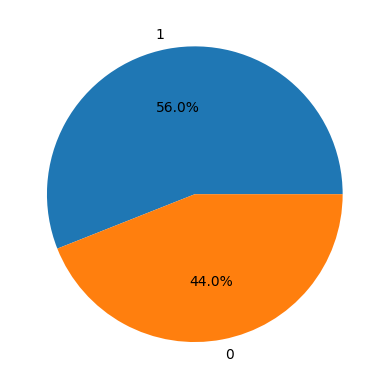

In [20]:
data['Research'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [22]:
data['University Rating'].value_counts() 

University Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

<Axes: >

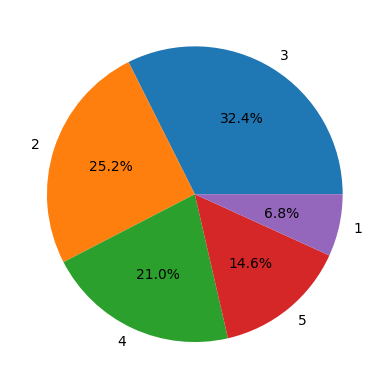

In [23]:
data['University Rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [27]:
data['SOP'].value_counts()

SOP
4.0    89
3.5    88
3.0    80
2.5    64
4.5    63
2.0    43
5.0    42
1.5    25
1.0     6
Name: count, dtype: int64

In [30]:
data['LOR '].value_counts()

LOR 
3.0    99
4.0    94
3.5    86
4.5    63
2.5    50
5.0    50
2.0    46
1.5    11
1.0     1
Name: count, dtype: int64

In [25]:
data=data.drop(columns=['Serial No.'])

In [26]:
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [31]:
X=data.iloc[:,0:7]
y=data.iloc[:,-1]

In [32]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [33]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
X_train_scaled

array([[0.62      , 0.67857143, 0.5       , ..., 0.71428571, 0.65064103,
        1.        ],
       [0.52      , 0.67857143, 0.75      , ..., 1.        , 0.55769231,
        0.        ],
       [0.26      , 0.35714286, 0.5       , ..., 0.42857143, 0.54487179,
        0.        ],
       ...,
       [0.24      , 0.25      , 0.        , ..., 0.14285714, 0.14423077,
        0.        ],
       [0.38      , 0.46428571, 0.25      , ..., 0.71428571, 0.28205128,
        0.        ],
       [0.48      , 0.5       , 0.25      , ..., 0.57142857, 0.46474359,
        0.        ]], shape=(400, 7))

In [38]:
X_test_scaled

array([[ 0.88      ,  0.85714286,  0.75      ,  0.75      ,  0.57142857,
         0.87820513,  1.        ],
       [ 0.48      ,  0.57142857,  0.75      ,  0.875     ,  0.71428571,
         0.71794872,  1.        ],
       [ 0.5       ,  0.46428571,  0.25      ,  0.25      ,  0.28571429,
         0.2724359 ,  0.        ],
       [ 0.44      ,  0.60714286,  0.5       ,  0.5       ,  0.42857143,
         0.60576923,  0.        ],
       [ 0.72      ,  0.71428571,  0.5       ,  0.625     ,  0.42857143,
         0.72115385,  1.        ],
       [ 0.78      ,  0.67857143,  0.75      ,  0.875     ,  0.71428571,
         0.77884615,  1.        ],
       [ 0.        ,  0.28571429,  0.        ,  0.125     ,  0.14285714,
         0.24358974,  0.        ],
       [ 0.22      ,  0.5       ,  0.75      ,  0.375     ,  0.42857143,
         0.53525641,  0.        ],
       [ 0.56      ,  0.60714286,  0.5       ,  0.625     ,  0.71428571,
         0.77564103,  1.        ],
       [ 0.6       ,  0.7142

In [64]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [65]:
X_train.shape 

(400, 7)

In [66]:
model=Sequential()
model.add(Dense(14,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(14,activation='relu'))
model.add(Dense(1,activation='linear'))

d:\Deep Learning\Graduate-Admission-Prediction\my_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history=model.compile(loss='mean_squared_error',optimizer='Adam')

In [69]:
history=model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=100)

Epoch 1/100


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7226 - val_loss: 0.6681
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5638 - val_loss: 0.5106
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4451 - val_loss: 0.4229
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3688 - val_loss: 0.3475
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2981 - val_loss: 0.2708
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2240 - val_loss: 0.1879
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1440 - val_loss: 0.1003
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0653 - val_loss: 0.0318
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0155 - val_loss: 0.0121
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0120 - val_loss: 0.0164
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100 - val_loss: 0.0100
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079 - val_l

In [70]:
y_pred=model.predict(X_test_scaled)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000026F734EBA60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [71]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)


0.7825250078743166

In [76]:
history.history

{'loss': [0.7225700616836548,
  0.5638349056243896,
  0.44513648748397827,
  0.3688147962093353,
  0.298098623752594,
  0.22401373088359833,
  0.14404752850532532,
  0.06532759964466095,
  0.015480590052902699,
  0.012046130374073982,
  0.009981031529605389,
  0.007931249216198921,
  0.007729764096438885,
  0.007237359881401062,
  0.0070411087945103645,
  0.006870175711810589,
  0.006720829755067825,
  0.006596554070711136,
  0.0064775035716593266,
  0.006361307110637426,
  0.006258494220674038,
  0.006144850514829159,
  0.006039009429514408,
  0.0059049855917692184,
  0.0058173732832074165,
  0.005712042097002268,
  0.005620989482849836,
  0.005564504768699408,
  0.005429346580058336,
  0.005342497490346432,
  0.005257990211248398,
  0.005186593625694513,
  0.005127374082803726,
  0.005076824687421322,
  0.004971337039023638,
  0.004922693595290184,
  0.004850341472774744,
  0.00483310641720891,
  0.004778927657753229,
  0.004722747020423412,
  0.004678418394178152,
  0.00463483575731

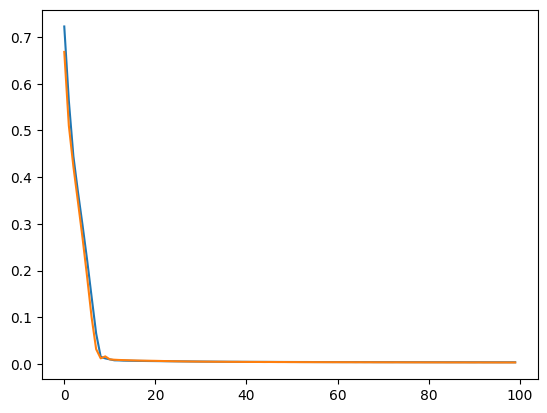

In [74]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])